# Employee Profile Breakdown

## INTRODUCTION

This file provides an analysis of employees based on their life and work traits, such as overtime work, distance between home and workplace, attrition, marital status and more.

In [1]:
# CHANGE USER_PATH

from pathlib import Path


USER_PATH = Path(r"C:\Users\Mateusz\Desktop\ZBIORCZE\TECH\ANALIZA DANYCH\Python\Projekty MB") 


df_path = USER_PATH / "Python Analysis of Employee Attrition and Performance" / "dataframe.csv"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks')

df=pd.read_csv(df_path)

### Employee Marital Status Analysis: Overtime Work and Business Travel

In [3]:
df_status = df[["MaritalStatus", "OverTime"]].copy() # extracting columns
df_travel = df[["MaritalStatus","BusinessTravel"]].copy() # extracting columns

marital_status = df["MaritalStatus"].unique() # unique values

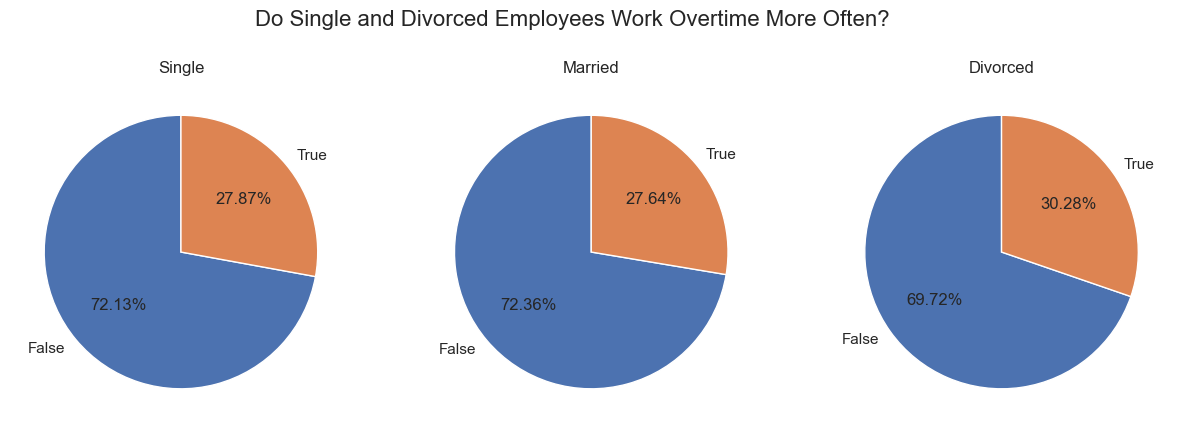

In [4]:
fig, ax = plt.subplots(1, len(marital_status))
fig.set_size_inches((15, 5))

# for loop to create a chart for each status

for i, status in enumerate(marital_status):
    ax[i].pie(df_status[df_status["MaritalStatus"] == marital_status[i]].value_counts(), labels=['False', 'True'], autopct='%1.2f%%', startangle=90)
    ax[i].set_title(status)

plt.suptitle("Do Single and Divorced Employees Work Overtime More Often?", fontsize=16)
plt.show()

In [5]:
df_travel.value_counts()

MaritalStatus  BusinessTravel   
Married        Travel Rarely        496
Single         Travel Rarely        327
Divorced       Travel Rarely        220
Married        Travel Frequently    118
Single         Travel Frequently     96
Divorced       Travel Frequently     63
Married        Non-Travel            59
Single         Non-Travel            47
Divorced       Non-Travel            44
Name: count, dtype: int64

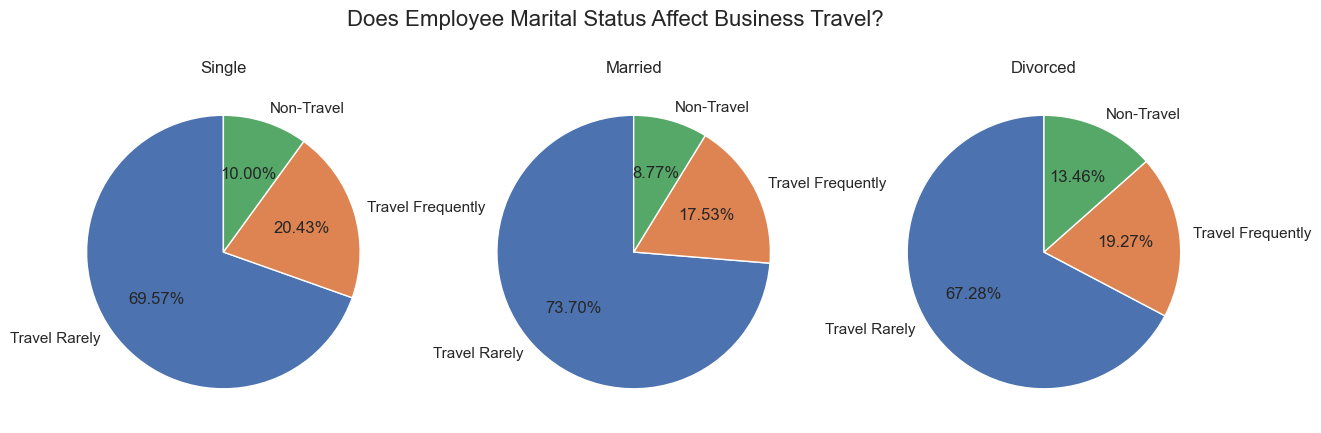

In [6]:
fig, ax = plt.subplots(1, len(marital_status))
fig.set_size_inches((15, 5))

# for loop to create a chart for each status 

for i, status in enumerate(marital_status):
    ax[i].pie(df_travel[df_travel["MaritalStatus"] == marital_status[i]].value_counts(), labels=["Travel Rarely", "Travel Frequently", "Non-Travel"], autopct='%1.2f%%', startangle=90)
    ax[i].set_title(status)

plt.suptitle("Does Employee Marital Status Affect Business Travel?", fontsize=16)
plt.show()

In [7]:
df_age = df[["Age", "Attrition"]].copy()

### Is Employee Age Associeted with Attrition?

In [8]:
# function that creates age groups depended on employee age

def age_group(age):
    if age < 25:
        return "1.Young Adults (18-24)" # numbers were added to order in correct order later on
    elif age < 35:
        return "2.Young Professionals (25-34)"
    elif age < 45:
        return "3.Early Adults (35-44)"
    elif age < 55:
        return "4.Middle Adults (45-54)"
    else:
        return "5.Older Adults (55-60)"

df_age["Age Group"] = df_age["Age"].apply(age_group) # new column

In [9]:
# pivote table (count)

df_age = df_age.pivot_table(
    index = "Age Group",
    columns="Attrition",
    aggfunc="count",
    sort=True)


In [10]:
# getting rid of numbers in age group column

df_age.reset_index(inplace=True)

df_age["Age Group"] = df_age["Age Group"].str[2:]

df_age.set_index(keys="Age Group", inplace=True)

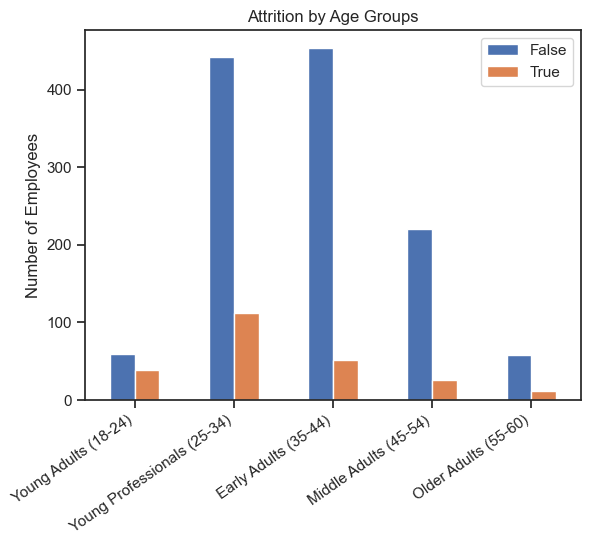

In [11]:
df_age.plot(kind = "bar")

plt.title("Attrition by Age Groups")
plt.ylabel("Number of Employees")
plt.xlabel("")

plt.legend(["False", "True"])

plt.xticks(rotation = 35, ha = "right")

plt.show()

### Salary Distributions for the Most Popular Job Roles

In [12]:
job_roles = df["JobRole"].value_counts().head(5).index.tolist() # top 5 roles in df (indexes converted to python list)

df_top5 = df[df["JobRole"].isin(job_roles)] # filtering df for roles in job_roles list

job_order = df_top5.groupby("JobRole")["MonthlyIncome"].median().sort_values(ascending=False).index # group by median monthly income

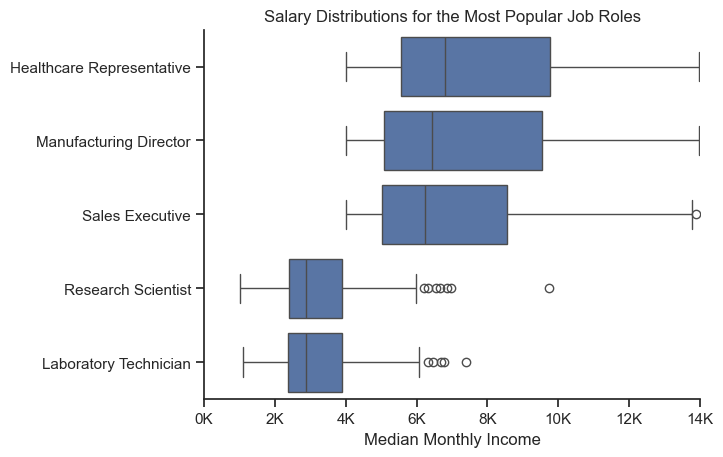

In [13]:
# boxplotting

sns.boxplot(data=df_top5, x="MonthlyIncome", y="JobRole", order=job_order)
sns.set_theme(style='ticks')
sns.despine()

plt.title("Salary Distributions for the Most Popular Job Roles")
plt.xlabel("Median Monthly Income")
plt.ylabel("")
plt.xlim(0, 14000) # x axis values

ticks_x = plt.FuncFormatter(lambda y, pos: f"{int(y/1000)}K") # 14000 -> 14K
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

### Employee Education by Gender

In [14]:
df_education = df[["Gender", "EducationField"]].copy()

In [15]:
# pivote table (size)

df_education = df_education.pivot_table(
    index="EducationField",
    columns="Gender",
    aggfunc="size"
)


In [16]:
# creating an additional column to sort values in right order

df_education = df_education.reset_index()

df_education["Sum"] = df_education["Male"] + df_education["Female"]

df_education.sort_values(by="Sum", ascending=False, inplace=True)

df_education = df_education[["EducationField", "Male", "Female"]]

df_education.set_index(keys="EducationField", inplace=True)

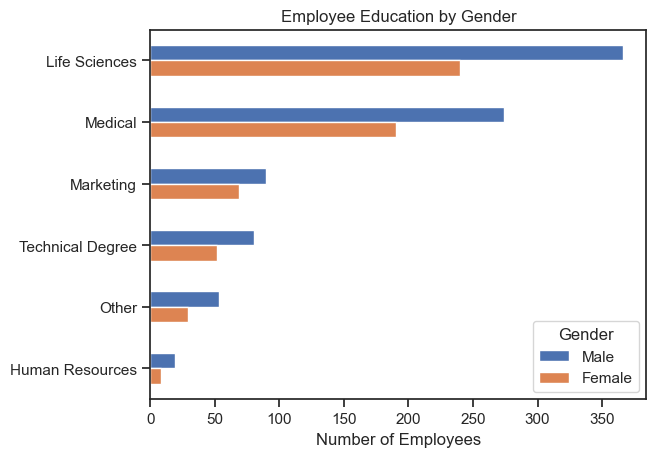

In [17]:
axis = df_education.plot(kind = "barh")

plt.title("Employee Education by Gender")
plt.ylabel("")
plt.xlabel("Number of Employees")
axis.invert_yaxis() # inverting results


plt.show()